### 1. 載入函示庫與資料

In [1]:
import pandas as pd
import numpy as np
from sqlalchemy import create_engine, text
import psycopg2
from datetime import datetime

# 顯示更完整的輸出
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)

print("✓ 導入完成")

✓ 導入完成


In [2]:
# 資料庫連接設定
# Docker Compose 已將 PostgreSQL 映射到 localhost:5432
DB_USER = "admin"
DB_PASSWORD = "password123"
DB_HOST = "localhost"
DB_PORT = "5432"
DB_NAME = "anime_warehouse"

# 建立連接字串
db_url = f"postgresql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"

try:
    engine = create_engine(db_url, pool_pre_ping=True)
    
    # 測試連接
    with engine.connect() as conn:
        result = conn.execute(text("SELECT 1"))
        conn.commit()
    
    print(f"✓ 資料庫連接成功")
    print(f"  主機: {DB_HOST}:{DB_PORT}")
    print(f"  資料庫: {DB_NAME}")
    print(f"  用戶: {DB_USER}")
    
except Exception as e:
    print(f"✗ 連接失敗: {e}")
    print("\n💡 提示:")
    print("  確保 Docker Compose 正在運行: docker compose up -d")
    raise

✓ 資料庫連接成功
  主機: localhost:5432
  資料庫: anime_warehouse
  用戶: admin


In [3]:
# 讀取兩個數據來源

# 1. 讀取乾淨的動畫列表視圖
print("讀取 v_clean_tv_animelist 視圖...")
query_view = """
SELECT * FROM public.v_clean_tv_animelist
LIMIT 5
"""
df_animelist = pd.read_sql_query(query_view, engine)
print(f"✓ 視圖讀取成功: {len(df_animelist)} 筆記錄（顯示前 5 筆）")
print(f"  欄位: {list(df_animelist.columns)}")
print()

# 2. 讀取動畫元數據表
print("讀取 anime_metadata 資料表...")
query_metadata = """
SELECT * FROM public.anime_metadata
LIMIT 5
"""
df_metadata = pd.read_sql_query(query_metadata, engine)
print(f"✓ 表格讀取成功: {len(df_metadata)} 筆記錄（顯示前 5 筆）")
print(f"  欄位: {list(df_metadata.columns)}")
print()

print("=" * 60)
print("完整的統計信息")
print("=" * 60)

# 獲取完整資料筆數
with engine.connect() as conn:
    result_view = conn.execute(text("SELECT COUNT(*) as count FROM public.v_clean_tv_animelist"))
    count_view = result_view.fetchone()[0]
    
    result_metadata = conn.execute(text("SELECT COUNT(*) as count FROM public.anime_metadata"))
    count_metadata = result_metadata.fetchone()[0]
    conn.commit()

print(f"v_clean_tv_animelist 視圖: {count_view:,} 筆動畫")
print(f"anime_metadata 表格: {count_metadata:,} 筆元數據")

讀取 v_clean_tv_animelist 視圖...
✓ 視圖讀取成功: 5 筆記錄（顯示前 5 筆）
  欄位: ['title', 'episodes', 'rating', 'mean_view_count', 'sum_view_count', 'churn_rate', 'frequency', 'aired_weekly', 'type', 'year', 'season', 'first_pub_date', 'last_pub_date', 'r18', 'url']

讀取 anime_metadata 資料表...
✓ 表格讀取成功: 5 筆記錄（顯示前 5 筆）
  欄位: ['title', 'url', 'agent', 'studio', 'tags', 'updated_at']

完整的統計信息
v_clean_tv_animelist 視圖: 1,362 筆動畫
anime_metadata 表格: 1,362 筆元數據


In [4]:
# 加載完整數據集用於機器學習

print("加載完整數據集...")

# 加載 v_clean_tv_animelist 視圖
df_animelist_full = pd.read_sql_query("SELECT * FROM public.v_clean_tv_animelist", engine)
print(f"✓ v_clean_tv_animelist: {df_animelist_full.shape[0]} 筆 × {df_animelist_full.shape[1]} 欄")

# 加載 anime_metadata 表格
df_metadata_full = pd.read_sql_query("SELECT * FROM public.anime_metadata", engine)
print(f"✓ anime_metadata: {df_metadata_full.shape[0]} 筆 × {df_metadata_full.shape[1]} 欄")

# 資料類型
print("\n【v_clean_tv_animelist 數據類型】")
print(df_animelist_full.dtypes)

print("\n【anime_metadata 數據類型】")
print(df_metadata_full.dtypes)

# 缺失值檢查
print("\n【v_clean_tv_animelist 缺失值】")
print(df_animelist_full.isnull().sum())

print("\n【anime_metadata 缺失值】")
print(df_metadata_full.isnull().sum())

加載完整數據集...
✓ v_clean_tv_animelist: 1362 筆 × 15 欄
✓ anime_metadata: 1362 筆 × 6 欄

【v_clean_tv_animelist 數據類型】
title                              str
episodes                         int64
rating                         float64
mean_view_count                float64
sum_view_count                 float64
churn_rate                         str
frequency                          str
aired_weekly                      bool
type                               str
year                           float64
season                             str
first_pub_date     datetime64[us, UTC]
last_pub_date      datetime64[us, UTC]
r18                               bool
url                                str
dtype: object

【anime_metadata 數據類型】
title                    str
url                      str
agent                    str
studio                   str
tags                  object
updated_at    datetime64[us]
dtype: object

【v_clean_tv_animelist 缺失值】
title                0
episodes             0
rating 

### 2.資料彙整與前處理

In [5]:
# 合併資料
df = pd.merge(df_animelist_full, df_metadata_full, on='title', how='inner')
print(f"\n✓ 合併完成: {df.shape[0]} 筆 × {df.shape[1]} 欄")
print(df.head())


✓ 合併完成: 1362 筆 × 20 欄
                           title  episodes  rating  mean_view_count  \
0                 鬼滅之刃 竈門炭治郎 立志篇        26     4.9        1267134.0   
1  進擊的巨人 The Final Season 完結篇 後篇         1     5.0        1220530.0   
2                       鬼滅之刃 遊郭篇        11     4.9        1086712.0   
3  進擊的巨人 The Final Season 完結篇 前篇         1     5.0        1037448.0   
4                           咒術迴戰        24     4.9        1000479.0   

   sum_view_count churn_rate frequency  aired_weekly  type    year season  \
0      32945484.0      33.6%    weekly          True   半年番  2019.0     春番   
1       1220530.0        N/A    weekly         False  短篇動畫     NaN    NaN   
2      11953832.0      22.7%    weekly          True    季番  2021.0     秋番   
3       1037448.0        N/A    weekly         False  短篇動畫     NaN    NaN   
4      24011486.0      37.8%    weekly          True   半年番  2020.0     秋番   

             first_pub_date             last_pub_date    r18  \
0 2019-04-06 16:00:00+0

In [6]:
# 整理資料：使用 type（不使用 episodes）
type_col = next((c for c in ['type', 'type_x', 'type_y'] if c in df.columns), None)
if type_col is None:
    raise KeyError("找不到 type 欄位（type/type_x/type_y）")

df = df[['title', type_col, 'rating', 'churn_rate', 'mean_view_count', 'tags', 'r18']].copy()
df.rename(columns={type_col: 'type'}, inplace=True)

df.replace(['N/A', 'n/a', 'nan', 'None', ''], np.nan, inplace=True)
df.dropna(subset=['churn_rate', 'type'], inplace=True)
df['churn_rate'] = df['churn_rate'].astype(str).str.strip('%').astype(float) / 100

df.head()

,title,type,rating,churn_rate,mean_view_count,tags,r18
0,鬼滅之刃 竈門炭治郎 立志篇,半年番,4.9,0.336,1267134.0,"[動作, 冒險, 奇幻, 血腥暴力]",False
2,鬼滅之刃 遊郭篇,季番,4.9,0.227,1086712.0,"[動作, 冒險, 奇幻, 血腥暴力]",False
4,咒術迴戰,半年番,4.9,0.378,1000479.0,"[動作, 奇幻, 超能力, 校園, 血腥暴力, 靈異神怪]",False
5,輝夜姬想讓人告白～天才們的戀愛頭腦戰～,季番,4.9,0.370,853700.0,"[校園, 喜劇, 戀愛]",False
6,輝夜姬想讓人告白～天才們的戀愛頭腦戰～ 第二季,季番,5.0,0.270,833028.0,"[校園, 喜劇, 戀愛]",False


<Axes: >

d:\Downloads\動畫瘋\AnimationDataProject\.venv\Lib\site-packages\IPython\core\events.py:100: UserWarning: Glyph 23395 (\N{CJK UNIFIED IDEOGRAPH-5B63}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
d:\Downloads\動畫瘋\AnimationDataProject\.venv\Lib\site-packages\IPython\core\events.py:100: UserWarning: Glyph 30058 (\N{CJK UNIFIED IDEOGRAPH-756A}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
d:\Downloads\動畫瘋\AnimationDataProject\.venv\Lib\site-packages\IPython\core\events.py:100: UserWarning: Glyph 21322 (\N{CJK UNIFIED IDEOGRAPH-534A}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
d:\Downloads\動畫瘋\AnimationDataProject\.venv\Lib\site-packages\IPython\core\events.py:100: UserWarning: Glyph 24180 (\N{CJK UNIFIED IDEOGRAPH-5E74}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
d:\Downloads\動畫瘋\AnimationDataProject\.venv\Lib\site-packages\IPython\core\events.py:100: UserWarning: Glyph 38263 (\N{CJK UNIFIED IDEOGRAPH-9577}) missing from font(s) DejaVu 

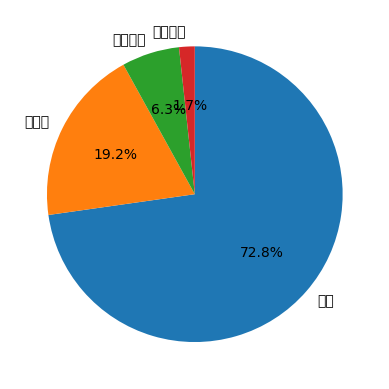

In [7]:
df.type.value_counts().plot.pie(autopct='%1.1f%%', startangle=90, counterclock=False)

In [8]:
import json

df['tags'] = df['tags'].apply(lambda x: json.loads(x) if isinstance(x, str) else x)
tags_one_hot = df['tags'].str.join('|').str.get_dummies()
type_order = ['短篇動畫', '季番', '半年番', '長篇動畫']
unknown = sorted(set(df['type'].dropna().unique()) - set(type_order))
if unknown:
    raise ValueError(f"type 欄位有未定義類別: {unknown}")
df['type'] = pd.Categorical(df['type'], categories=type_order, ordered=True)
df['type_ord'] = df['type'].cat.codes  # 0,1,2,3
df_final = pd.concat([df.drop(columns=['tags', 'type']), tags_one_hot], axis=1)
df_final.set_index('title', inplace=True)
df_final['r18'] = df_final['r18'].astype(int)

print("type 有序編碼完成：", dict(enumerate(type_order)))

type 有序編碼完成： {0: '短篇動畫', 1: '季番', 2: '半年番', 3: '長篇動畫'}


In [9]:
df_final = df_final[df_final['真人演出'] == 0]
df_final.drop('真人演出', axis=1, inplace=True)

### 3. 描述統計量

In [10]:
df_final.describe()

,rating,churn_rate,mean_view_count,r18,type_ord,BL,GL,偶像,冒險,動作,勵志,喜劇,奇幻,悠閒,感人,懸疑,戀愛,戰爭,推理,料理,時間穿越,校園,機甲,歷史,泡麵番,溫馨,特攝,異世界,科幻,競技,職場,血腥暴力,親情,超能力,運動,闔家觀賞,靈異神怪,青春,音樂,魔法,黑暗
count,1310.000000,1310.000000,1.310000e+03,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000
mean,4.585344,0.545335,1.025984e+05,0.010687,1.281679,0.008397,0.007634,0.038168,0.300763,0.244275,0.123664,0.265649,0.343511,0.072519,0.023664,0.061069,0.207634,0.037405,0.041221,0.026718,0.016794,0.254962,0.026718,0.019084,0.055725,0.117557,0.004580,0.111450,0.100763,0.074046,0.064122,0.060305,0.029771,0.067176,0.070229,0.078626,0.070992,0.148855,0.054962,0.151908,0.051145
std,0.458731,0.171262,1.379070e+05,0.102863,0.580469,0.091284,0.087070,0.191675,0.458765,0.429820,0.329324,0.441847,0.475062,0.259445,0.152058,0.239548,0.405768,0.189824,0.198878,0.161318,0.128548,0.436006,0.161318,0.136872,0.229478,0.322206,0.067547,0.314809,0.301130,0.261945,0.245064,0.238143,0.170020,0.250421,0.255630,0.269257,0.256910,0.356081,0.227993,0.359069,0.220378
min,1.500000,0.102000,9.300000e+01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.500000,0.420250,1.822100e+04,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,4.700000,0.542500,5.577350e+04,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,4.900000,0.663750,1.318858e+05,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,5.000000,0.986000,1.267134e+06,1.000000,3.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [11]:
len(df_final.columns)

41

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei']

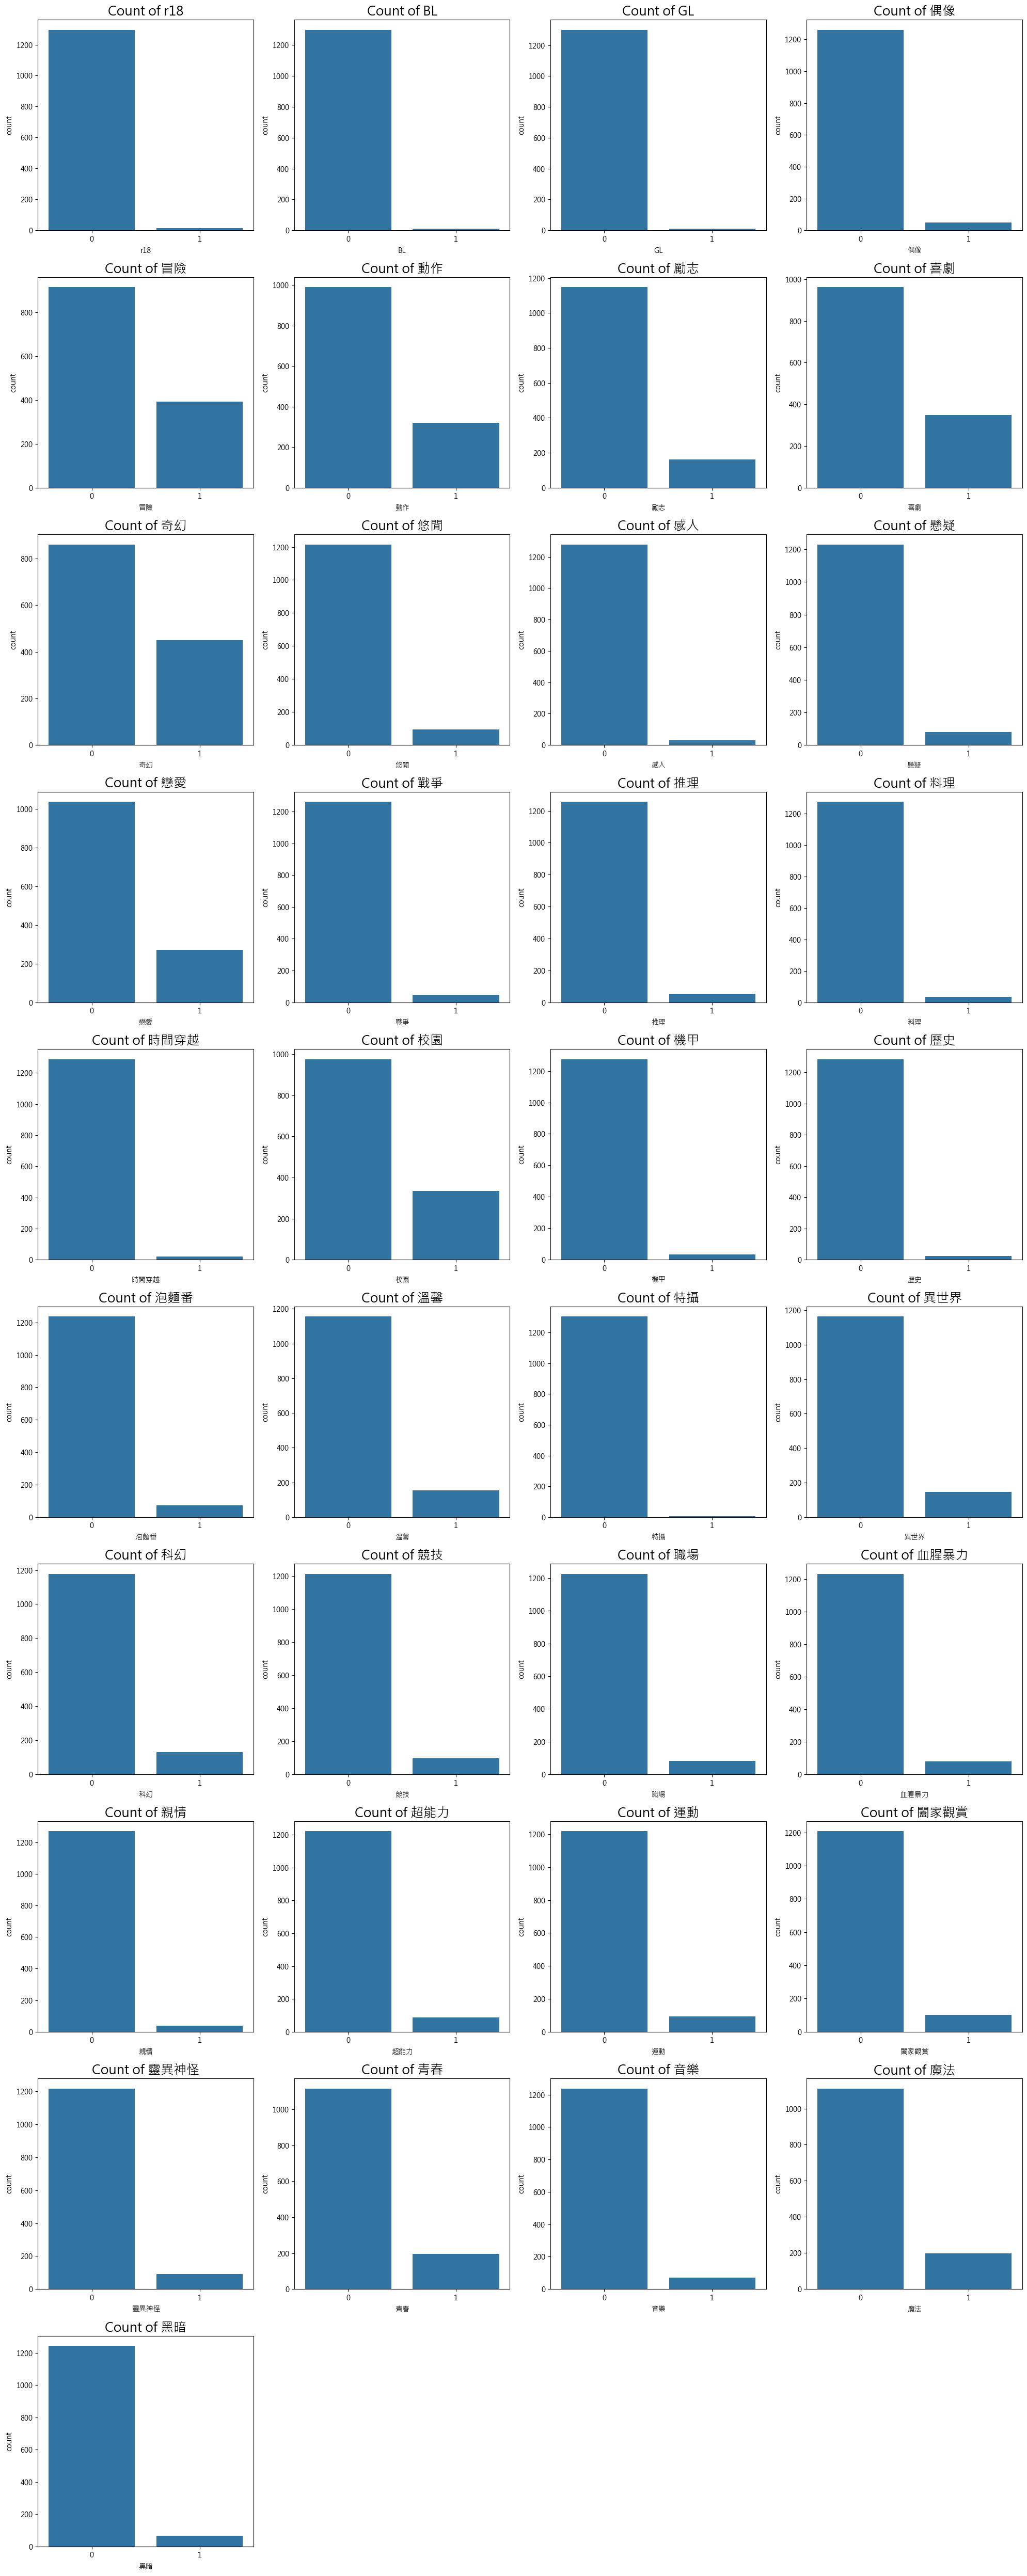

In [13]:
cols_to_plot = ['r18', 'BL','GL', '偶像', '冒險', '動作', '勵志', '喜劇', '奇幻', '悠閒',
                '感人', '懸疑', '戀愛', '戰爭','推理', '料理', '時間穿越', '校園', '機甲',
                '歷史', '泡麵番', '溫馨', '特攝', '異世界', '科幻', '競技', '職場',
                '血腥暴力', '親情', '超能力', '運動', '闔家觀賞', '靈異神怪', '青春', '音樂',
                '魔法', '黑暗']

fig, axes = plt.subplots(10, 4, figsize=(20, 50))
axes = axes.flatten()

for i, col in enumerate(cols_to_plot):

    sns.countplot(data=df_final, x=col, ax=axes[i])
    axes[i].set_title(f'Count of {col}',fontdict={'fontsize': 18})

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout() 
plt.show()

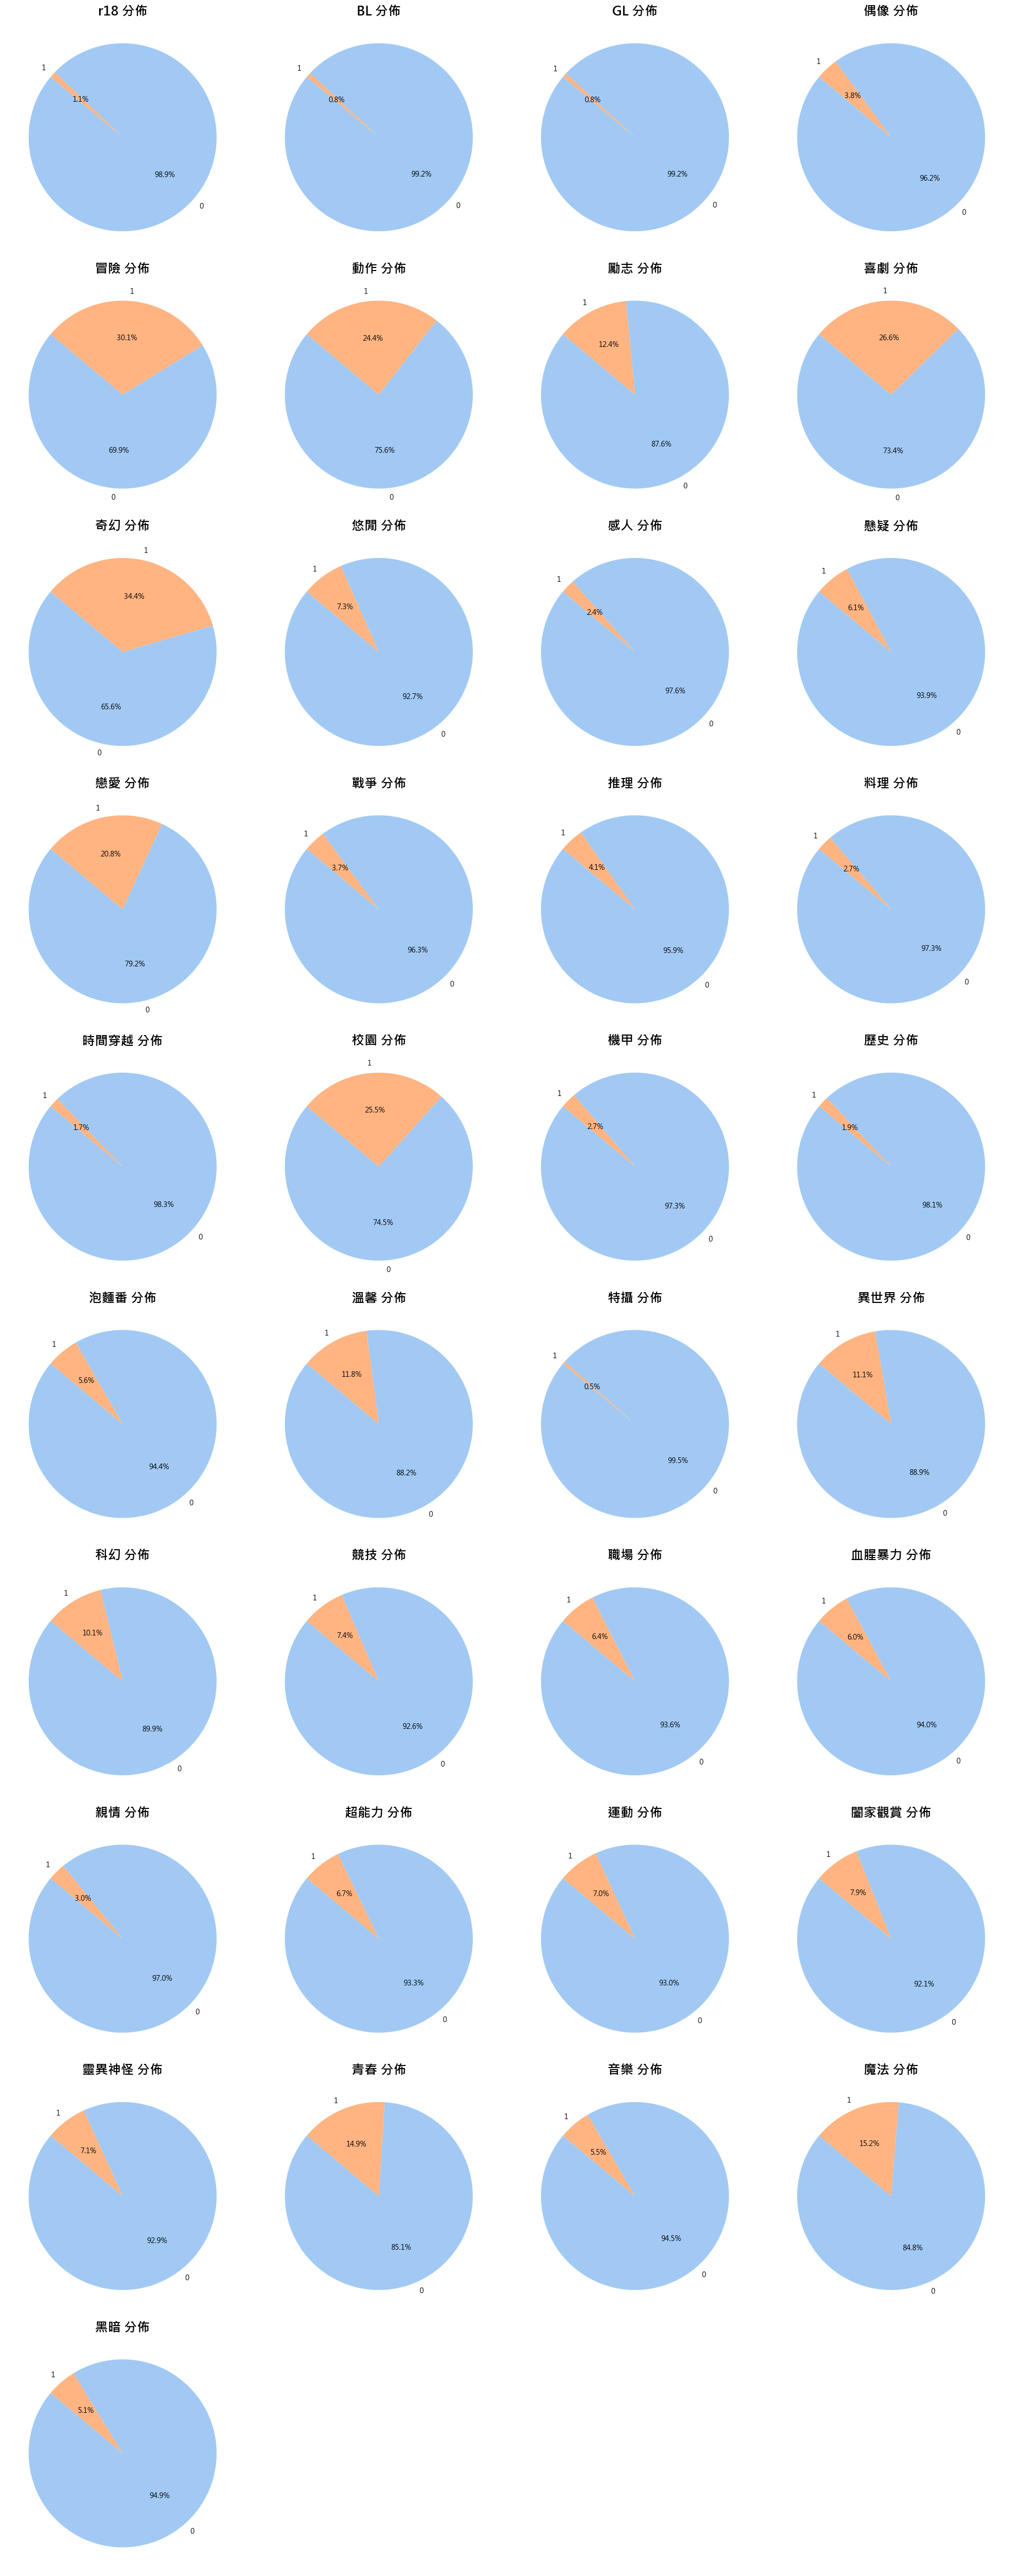

In [14]:
fig, axes = plt.subplots(10, 4, figsize=(20, 50))
axes = axes.flatten()
colors = sns.color_palette('pastel')

for i, col in enumerate(cols_to_plot):
    counts = df_final[col].value_counts()
    axes[i].pie(counts, labels=counts.index, autopct='%1.1f%%', 
                startangle=140, colors=colors)
    axes[i].set_title(f'{col} 分佈', fontdict={'fontsize': 18, 'fontweight': 'bold'})
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

<Axes: xlabel='churn_rate', ylabel='Count'>

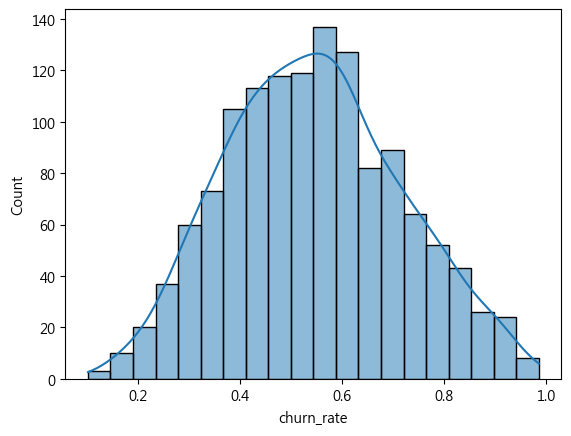

In [15]:
sns.histplot(df_final['churn_rate'], bins=20, kde=True)

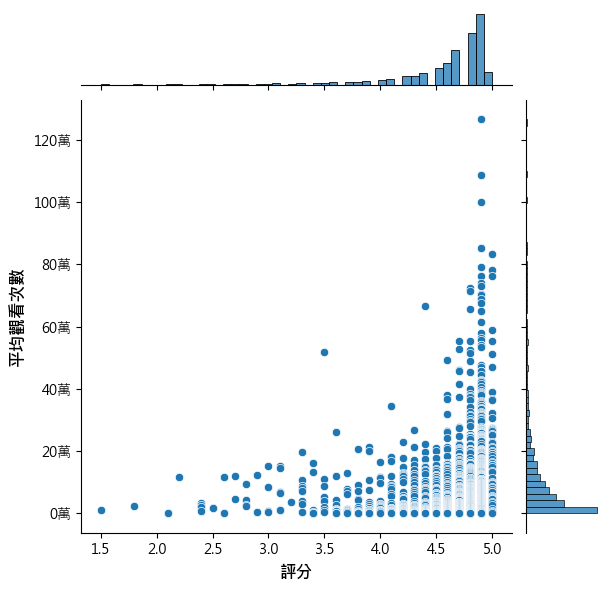

In [16]:
import matplotlib.ticker as ticker

g = sns.jointplot(data=df_final, x='rating', y='mean_view_count', kind='scatter')
g.ax_joint.set_xlabel('評分', fontdict={'fontsize': 12, 'fontweight': 'bold'})
g.ax_joint.set_ylabel('平均觀看次數', fontdict={'fontsize': 12, 'fontweight': 'bold'})
g.ax_joint.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x/1e4:g}萬'))


In [17]:
df_final.describe()

,rating,churn_rate,mean_view_count,r18,type_ord,BL,GL,偶像,冒險,動作,勵志,喜劇,奇幻,悠閒,感人,懸疑,戀愛,戰爭,推理,料理,時間穿越,校園,機甲,歷史,泡麵番,溫馨,特攝,異世界,科幻,競技,職場,血腥暴力,親情,超能力,運動,闔家觀賞,靈異神怪,青春,音樂,魔法,黑暗
count,1310.000000,1310.000000,1.310000e+03,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000
mean,4.585344,0.545335,1.025984e+05,0.010687,1.281679,0.008397,0.007634,0.038168,0.300763,0.244275,0.123664,0.265649,0.343511,0.072519,0.023664,0.061069,0.207634,0.037405,0.041221,0.026718,0.016794,0.254962,0.026718,0.019084,0.055725,0.117557,0.004580,0.111450,0.100763,0.074046,0.064122,0.060305,0.029771,0.067176,0.070229,0.078626,0.070992,0.148855,0.054962,0.151908,0.051145
std,0.458731,0.171262,1.379070e+05,0.102863,0.580469,0.091284,0.087070,0.191675,0.458765,0.429820,0.329324,0.441847,0.475062,0.259445,0.152058,0.239548,0.405768,0.189824,0.198878,0.161318,0.128548,0.436006,0.161318,0.136872,0.229478,0.322206,0.067547,0.314809,0.301130,0.261945,0.245064,0.238143,0.170020,0.250421,0.255630,0.269257,0.256910,0.356081,0.227993,0.359069,0.220378
min,1.500000,0.102000,9.300000e+01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.500000,0.420250,1.822100e+04,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,4.700000,0.542500,5.577350e+04,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,4.900000,0.663750,1.318858e+05,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,5.000000,0.986000,1.267134e+06,1.000000,3.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


d:\Downloads\動畫瘋\AnimationDataProject\.venv\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Microsoft JhengHei.
  fig.canvas.draw()
d:\Downloads\動畫瘋\AnimationDataProject\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Microsoft JhengHei.
  fig.canvas.print_figure(bytes_io, **kw)


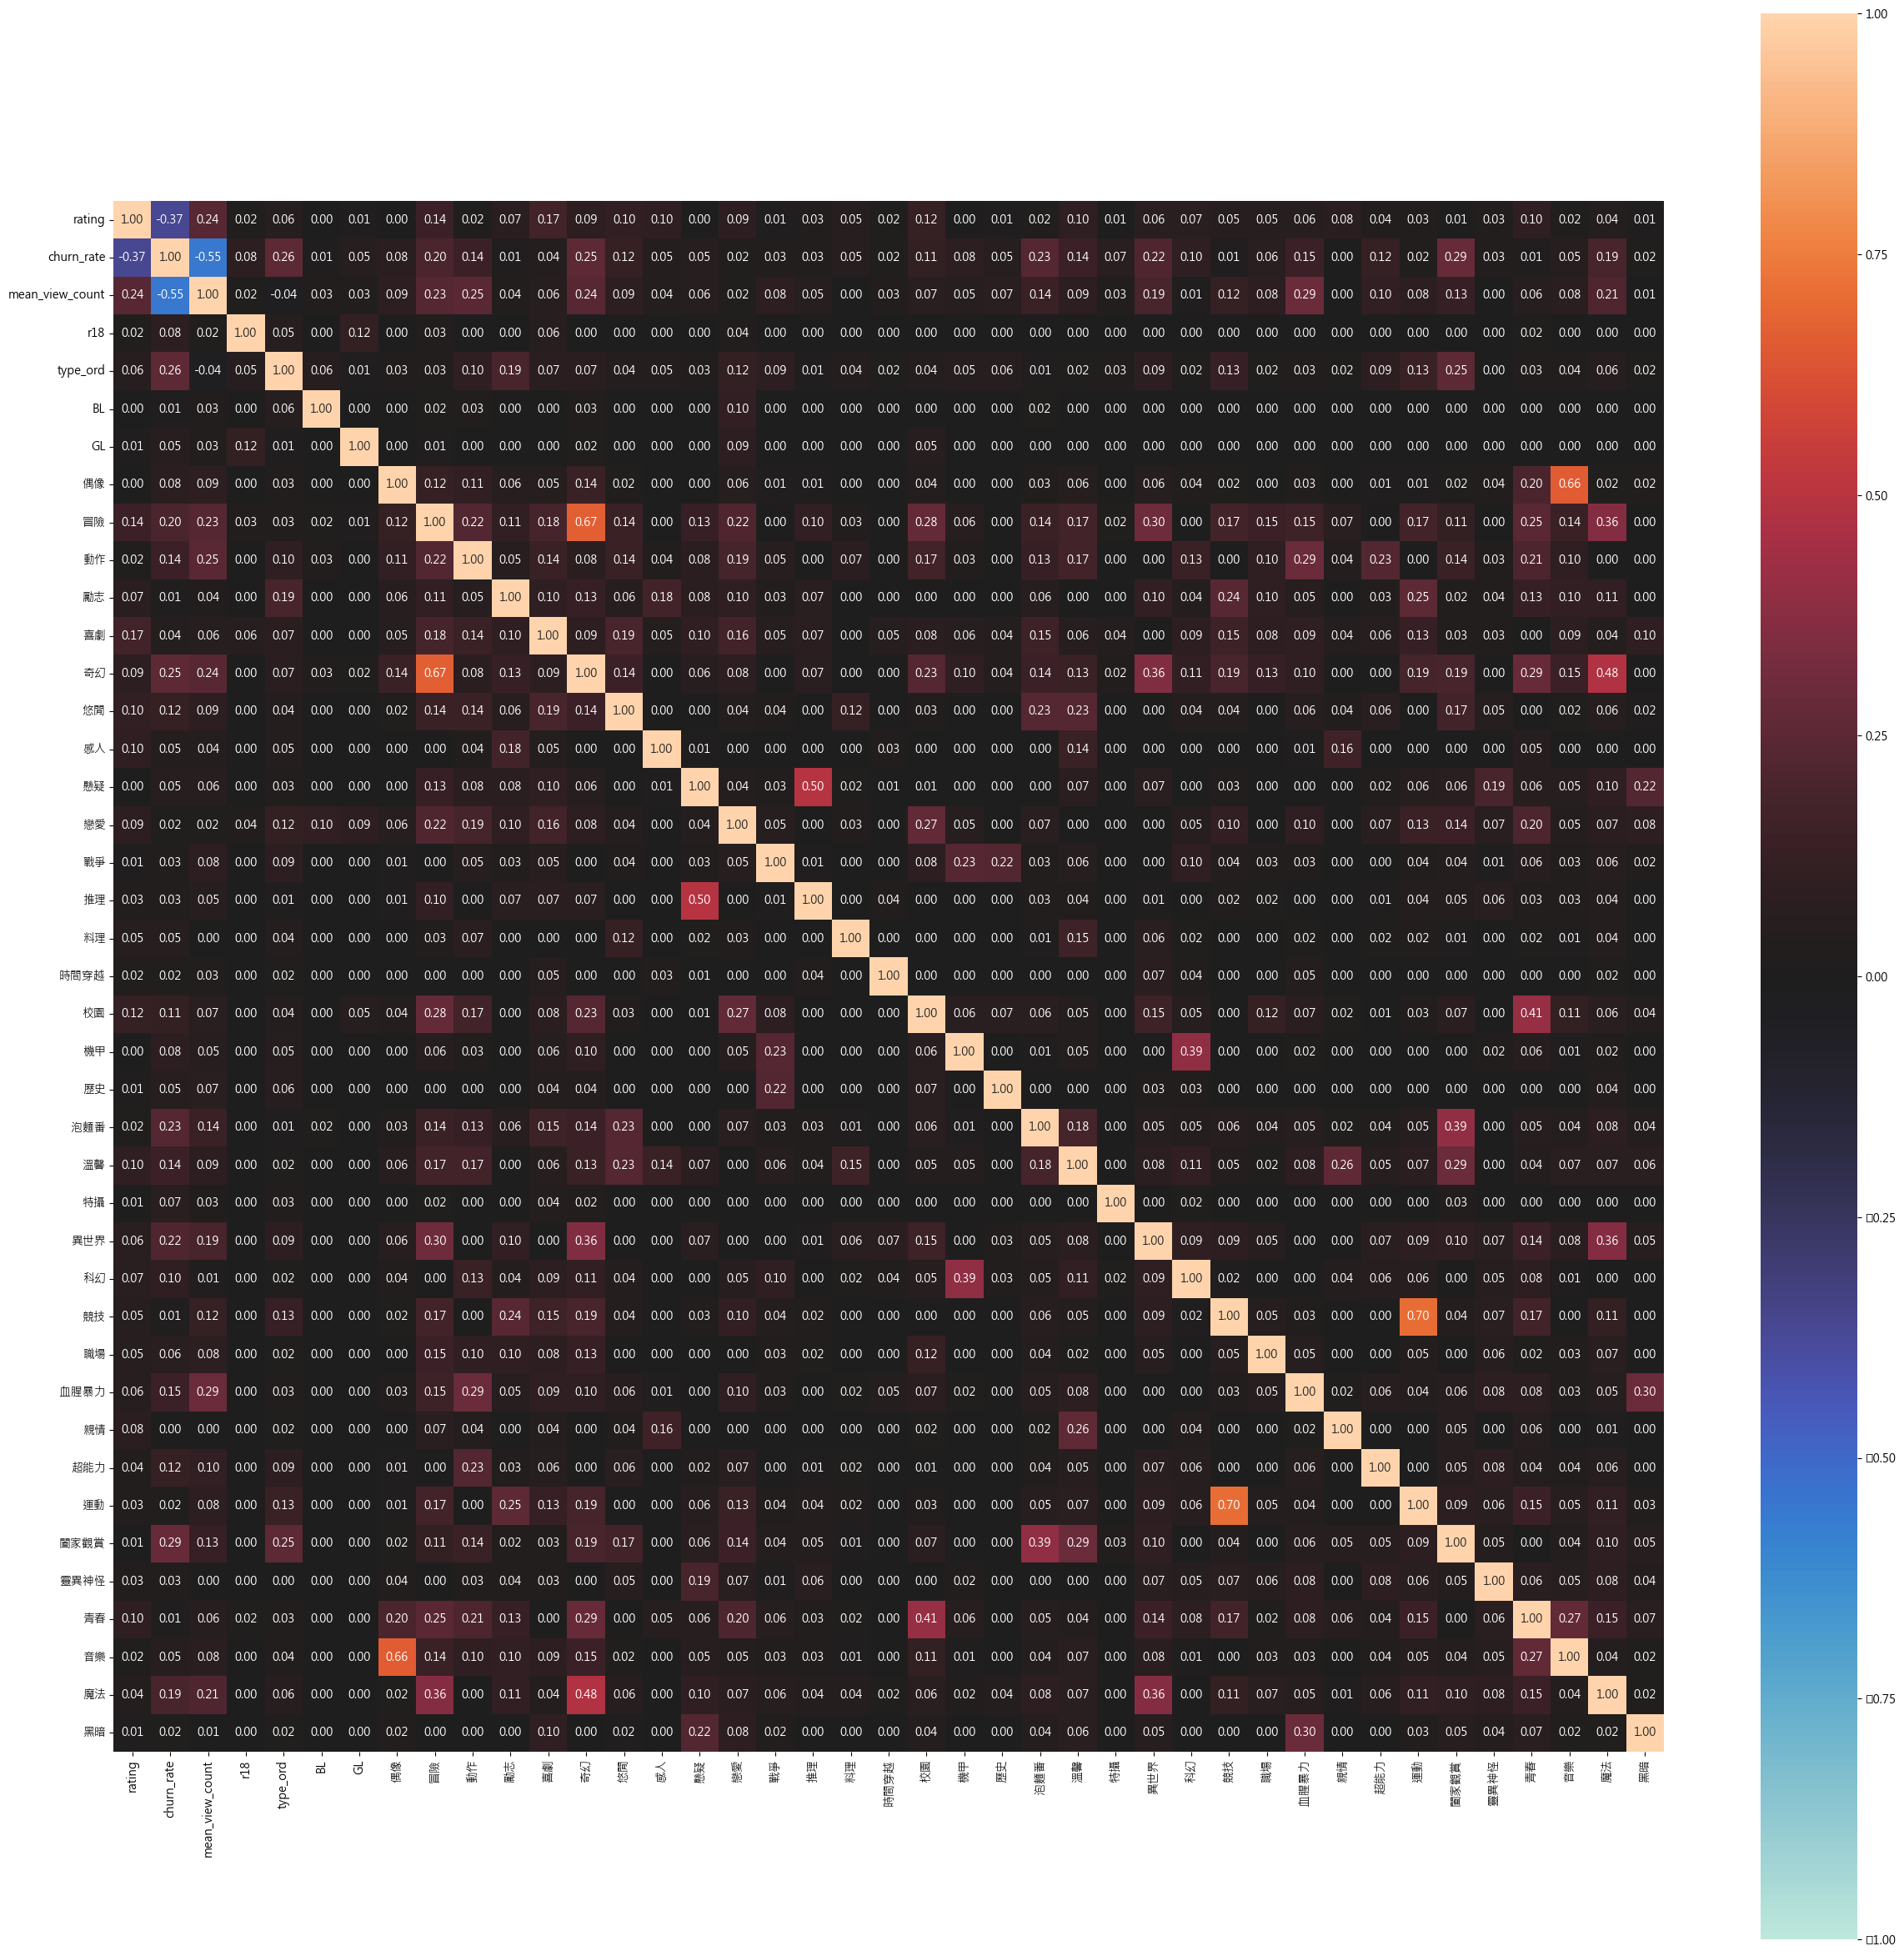

In [18]:
from dython.nominal import associations
results = associations(df_final, 
                       nominal_columns=cols_to_plot,
                       figsize=(30, 30))
theils_u_matrix = results['corr']


### 4.特徵工程

##### 對連續屬性做變數變換與標準化

In [19]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PowerTransformer
scaler = StandardScaler()
pt = PowerTransformer(method='box-cox', standardize=True)
df_final['mean_view_count'] = np.log10(df_final['mean_view_count'])
df_final['rating'] = pt.fit_transform(df_final[['rating']])
df_final['churn_rate'] = scaler.fit_transform(df_final[['churn_rate']])
df_final['mean_view_count'] = scaler.fit_transform(df_final[['mean_view_count']])

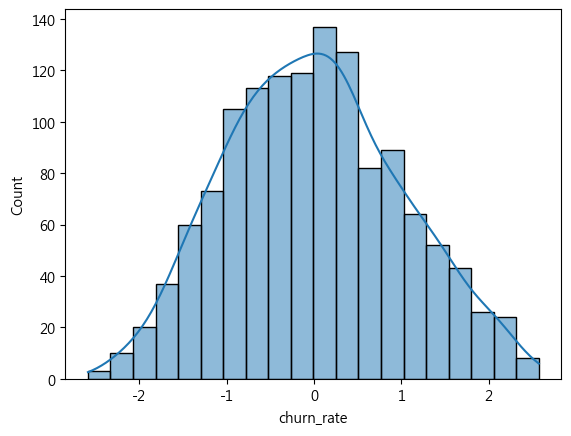

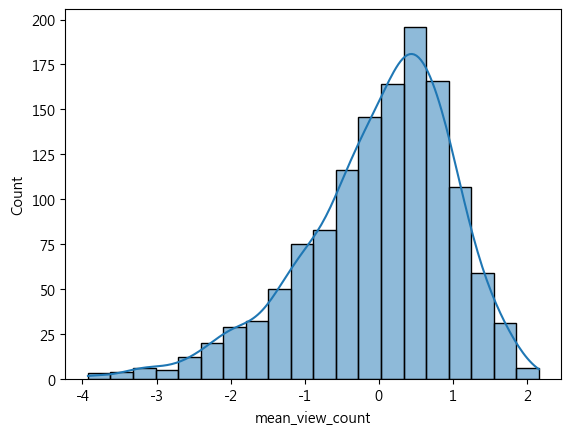

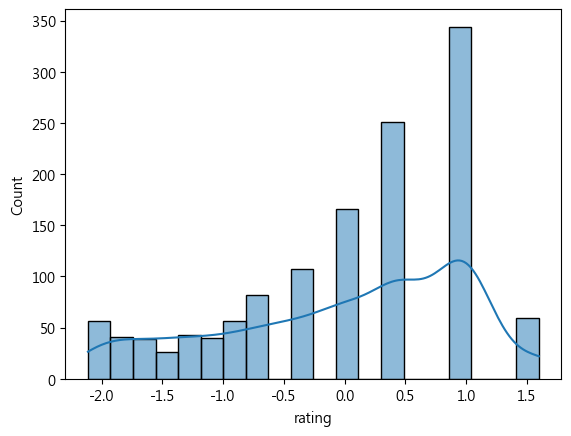

In [20]:
plt.rcParams['axes.unicode_minus'] = False
sns.histplot(df_final['churn_rate'], bins=20, kde=True)
plt.show()
sns.histplot(df_final['mean_view_count'], bins=20, kde=True)
plt.show()
sns.histplot(df_final['rating'], bins=20, kde=True)
plt.show()

##### 給類別變數加權

In [21]:
for icol, col in enumerate(cols_to_plot):
    df_final[col] = df_final[col]*0.3
df_final['type_ord'] = df_final['type_ord']*0.5

In [22]:
df_final.head()

,rating,churn_rate,mean_view_count,r18,type_ord,BL,GL,偶像,冒險,動作,勵志,喜劇,奇幻,悠閒,感人,懸疑,戀愛,戰爭,推理,料理,時間穿越,校園,機甲,歷史,泡麵番,溫馨,特攝,異世界,科幻,競技,職場,血腥暴力,親情,超能力,運動,闔家觀賞,靈異神怪,青春,音樂,魔法,黑暗
title,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
鬼滅之刃 竈門炭治郎 立志篇,0.979587,-1.222777,2.160215,0.0,1.0,0.0,0.0,0.0,0.3,0.3,0.0,0.0,0.3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
鬼滅之刃 遊郭篇,0.979587,-1.859473,2.062016,0.0,0.5,0.0,0.0,0.0,0.3,0.3,0.0,0.0,0.3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
咒術迴戰,0.979587,-0.977445,2.009159,0.0,1.0,0.0,0.0,0.0,0.0,0.3,0.0,0.0,0.3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.3,0.0,0.3,0.0,0.0,0.3,0.0,0.0,0.0,0.0
輝夜姬想讓人告白～天才們的戀愛頭腦戰～,0.979587,-1.024175,1.907730,0.0,0.5,0.0,0.0,0.0,0.0,0.0,0.0,0.3,0.0,0.0,0.0,0.0,0.3,0.0,0.0,0.0,0.0,0.3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
輝夜姬想讓人告白～天才們的戀愛頭腦戰～ 第二季,1.598937,-1.608299,1.892059,0.0,0.5,0.0,0.0,0.0,0.0,0.0,0.0,0.3,0.0,0.0,0.0,0.0,0.3,0.0,0.0,0.0,0.0,0.3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### 5.降維

##### PCA

In [ ]:
from sklearn.decomposition import PCA

pca = PCA()
pca.fit(df_final)

# 觀察「累積解釋變異量」
import numpy as np
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
cumulative_variance
# 看看要幾個維度才能達到 80% 的解釋力？
# 如果需要 20 個，代表作品真的很獨特；如果只要 8 個，代表主題還是很集中的。

num_components_80 = np.argmax(cumulative_variance >= 0.9) + 1
print(f"達到 80% 解釋力需要的主成分數量: {num_components_80}")

達到 80% 解釋力需要的主成分數量: 3


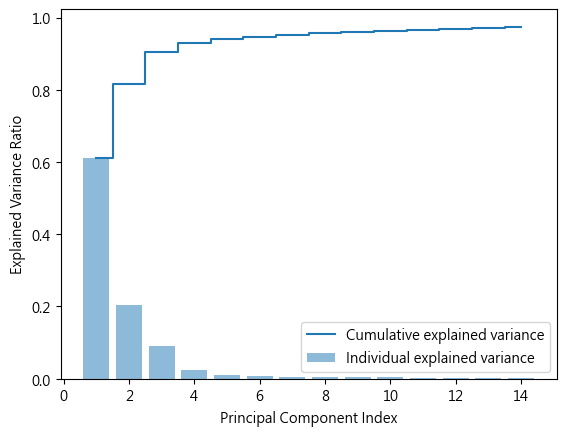

In [40]:
plt.bar(range(1, 15), pca.explained_variance_ratio_[:14], alpha=0.5, align='center', label='Individual explained variance')
plt.step(range(1, 15), cumulative_variance[:14], where='mid', label='Cumulative explained variance')
plt.xlabel('Principal Component Index')
plt.ylabel('Explained Variance Ratio')
plt.legend(loc='best')
plt.show()

In [37]:
X_pca = pca.fit_transform(df_final)[:, :4]
X_pca.shape

(1310, 4)

##### t-SNE

In [181]:
from sklearn.manifold import TSNE
tsne = TSNE(n_components=2, perplexity=40, random_state=42)
X_tsne = tsne.fit_transform(X_pca)

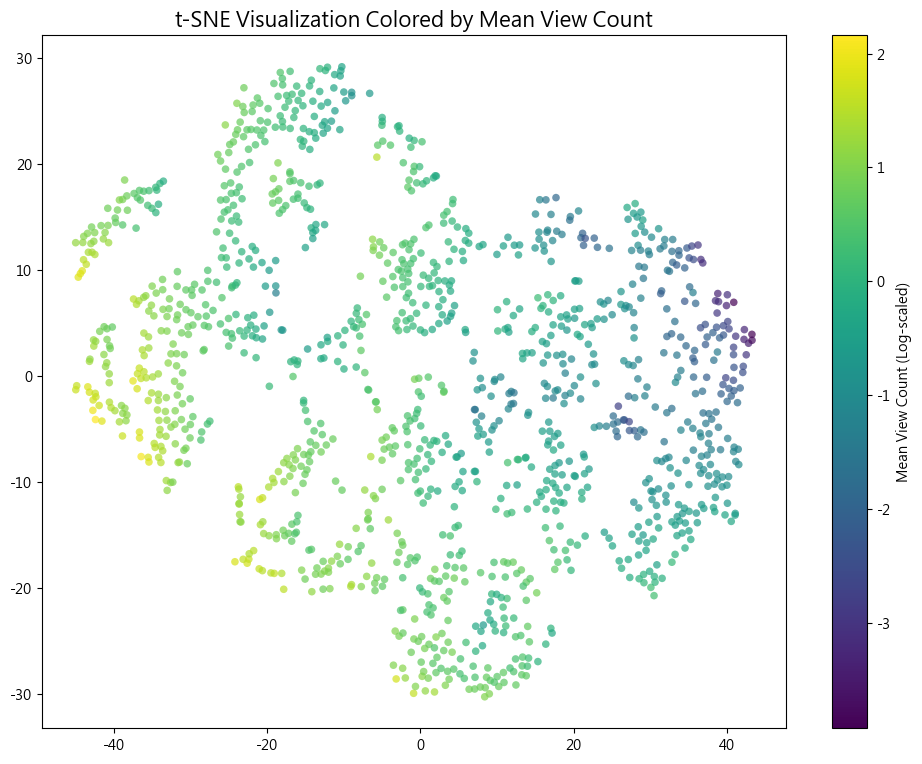

In [182]:
# ...existing code...
fig, ax = plt.subplots(figsize=(12, 9))

scatter = sns.scatterplot(
    x=X_tsne[:, 0],
    y=X_tsne[:, 1],
    hue=df_final['mean_view_count'],
    palette='viridis',
    s=30,
    alpha=0.7,
    edgecolor='none',
    ax=ax
)

norm = plt.Normalize(df_final['mean_view_count'].min(), df_final['mean_view_count'].max())
sm = plt.cm.ScalarMappable(cmap='viridis', norm=norm)
sm.set_array([])

if scatter.legend_ is not None:
    scatter.legend_.remove()

fig.colorbar(sm, ax=ax, label='Mean View Count (Log-scaled)')
ax.set_title('t-SNE Visualization Colored by Mean View Count', fontsize=15)
plt.show()
# ...existing code...

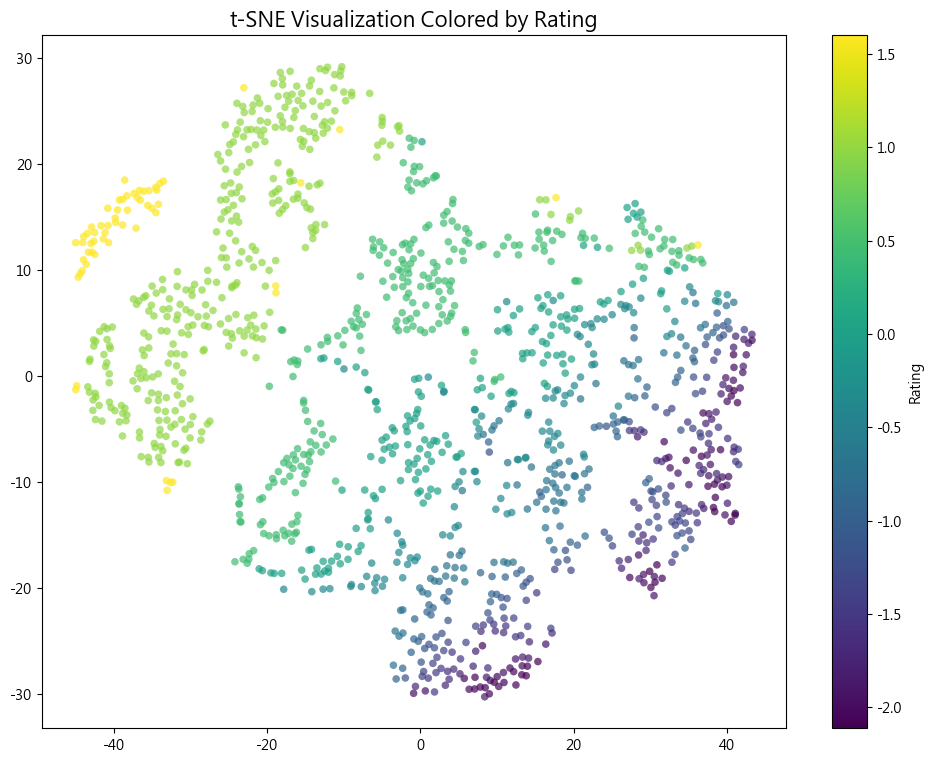

In [183]:
# ...existing code...
fig, ax = plt.subplots(figsize=(12, 9))

scatter = sns.scatterplot(
    x=X_tsne[:, 0],
    y=X_tsne[:, 1],
    hue=df_final['rating'],
    palette='viridis',
    s=30,
    alpha=0.7,
    edgecolor='none',
    ax=ax
)

norm = plt.Normalize(df_final['rating'].min(), df_final['rating'].max())
sm = plt.cm.ScalarMappable(cmap='viridis', norm=norm)
sm.set_array([])

if scatter.legend_ is not None:
    scatter.legend_.remove()

fig.colorbar(sm, ax=ax, label='Rating')
ax.set_title('t-SNE Visualization Colored by Rating', fontsize=15)
plt.show()
# ...existing code...

Text(0.5, 1.0, 't-SNE Visualization of Anime Data')

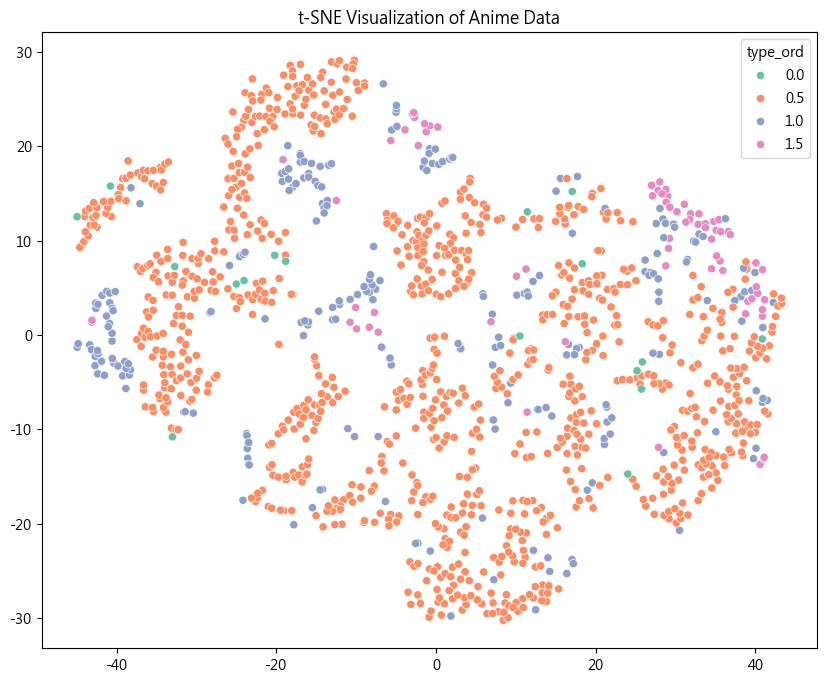

In [184]:
plt.figure(figsize=(10, 8))
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=df_final['type_ord'], palette='Set2')
plt.title('t-SNE Visualization of Anime Data')

### 6.分群

##### HDBSCAN
    HDBSCAN 是一種基於密度的聚類算法，可以自動識別不同密度的群集，並且能夠處理噪聲數據。
選擇使用它而非其他分群演算法的理由是這種基於密度的分群法更能捕捉到不規則形狀的群，
而HDBSCAN在邊界距離的調整上比起DBSCAN更加靈活。
以下是使用 HDBSCAN 進行聚類分析的示例代碼：

In [185]:
from sklearn.cluster import HDBSCAN

hdb = HDBSCAN(min_cluster_size=30, min_samples=3)
cluster_labels = hdb.fit_predict(X_pca)

df_final = df_final.copy()
df_final['cluster_labels'] = cluster_labels

n_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
print(f"總共分出了 {n_clusters} 個動漫集群")
print(df_final['cluster_labels'].value_counts().sort_index())

總共分出了 6 個動漫集群
cluster_labels
-1    396
 0     48
 1     64
 2    237
 3    185
 4     97
 5    283
Name: count, dtype: int64


d:\Downloads\動畫瘋\AnimationDataProject\.venv\Lib\site-packages\sklearn\cluster\_hdbscan\hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(


Text(0.5, 1.0, 't-SNE Visualization of Anime Clusters grouped by HDBSCAN')

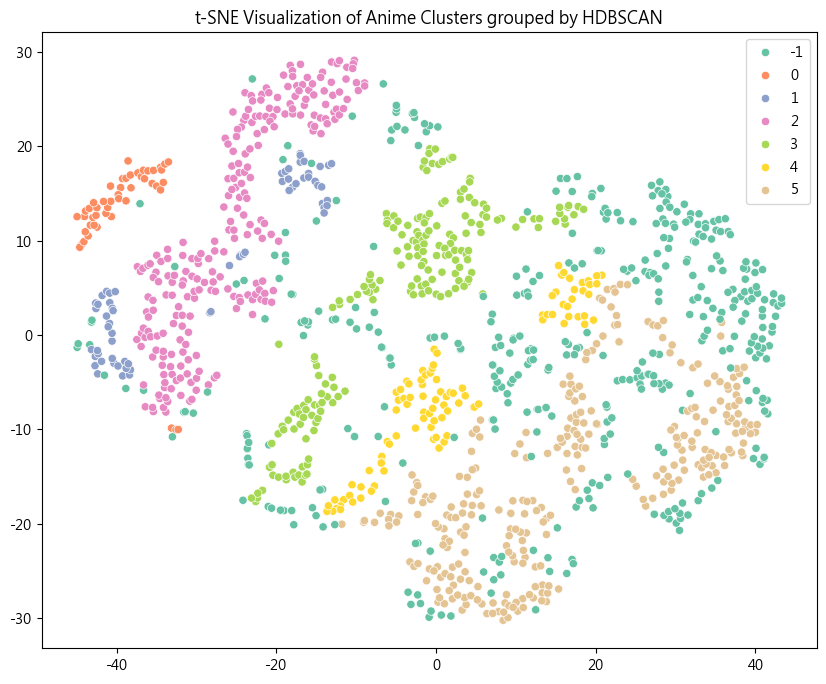

In [186]:
plt.figure(figsize=(10, 8))
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=cluster_labels, palette='Set2')
plt.title('t-SNE Visualization of Anime Clusters grouped by HDBSCAN')

In [187]:
# 只看有效群（排除 -1 噪音）
df_clustered = df_final[df_final['cluster_labels'] != -1].copy()

analysis = df_clustered.groupby('cluster_labels').agg({
    'mean_view_count': 'mean',
    'rating': 'mean',
    'churn_rate': 'mean',
    'type_ord': 'mean'
}).round(3)

print(analysis)

# tag 欄位（避免未定義 tag_cols）
tag_cols = [c for c in cols_to_plot if c in df_clustered.columns]
tag_means = df_clustered.groupby('cluster_labels')[tag_cols].mean()

for cid in tag_means.index:
    top_tags = tag_means.loc[cid].sort_values(ascending=False).head(3).index.tolist()
    print(f"Cluster {cid} 的前三大題材: {top_tags}")

                mean_view_count  rating  churn_rate  type_ord
cluster_labels                                               
0                         0.864   1.599      -1.044     0.490
1                         0.760   0.980      -0.498     1.000
2                         0.550   0.980      -0.546     0.500
3                         0.307   0.454      -0.179     0.573
4                         0.208   0.009      -0.074     0.500
5                        -0.112  -1.120       0.260     0.500
Cluster 0 的前三大題材: ['喜劇', '校園', '青春']
Cluster 1 的前三大題材: ['奇幻', '冒險', '動作']
Cluster 2 的前三大題材: ['喜劇', '奇幻', '校園']
Cluster 3 的前三大題材: ['喜劇', '校園', '奇幻']
Cluster 4 的前三大題材: ['奇幻', '校園', '冒險']
Cluster 5 的前三大題材: ['奇幻', '冒險', '動作']
